# Automated SAR Oil Spill Detection, Drift Hindcasting & AIS Vessel Attribution

**End-to-end pipeline notebook** following the project plan:

1. **Phase 1 – ML Detection**: Refined Deep-SAR Oil Spill (SOS) dataset → U-Net (ResNet34) → binary mask → OpenCV contours → centroid
2. **Phase 2 – Hindcasting**: Lagrangian reverse drift (OpenDrift-style / simplified physics) → origin point & time window
3. **Phase 3 – AIS Attribution**: Spatio-temporal filter + Suspicion Index scoring → top suspect vessel
4. **Phase 4 – Visualization**: Map + summary panel (Folium / matplotlib)

**Dataset**: [Refined Deep-SAR Oil Spill (SOS)](https://zenodo.org/records/15298010)  
**Stack**: PyTorch, segmentation-models-pytorch, OpenCV, GeoPandas, Pandas, Folium


## 0. Environment Setup

In [1]:
# Run once – install required packages
!pip install -q ultralytics segmentation-models-pytorch opencv-python-headless \
    albumentations geopandas shapely folium xarray netCDF4 \
    scikit-image scikit-learn matplotlib seaborn tqdm pillow rasterio torchmetrics
print("Packages ready")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 88.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00
Packages ready


In [2]:
import os, sys, json, warnings, zipfile, urllib.request
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

ROOT = Path("./raw_data")
DATA_DIR = ROOT
MODEL_DIR = ROOT / "models"
OUT_DIR = ROOT / "outputs"
for d in [DATA_DIR, MODEL_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


Device: cuda
PyTorch: 2.10.0+cu128


## 1. Dataset – Refined Deep-SAR Oil Spill (SOS)

Download from Zenodo (or place the zips manually if bandwidth is limited).

- `images.zip` (~1.1 GB)
- `masks.zip` (~28 MB)

Structure after extraction:
```
data/sos/
  images/   *.jpg / *.png / *.tif
  masks/    matching binary masks
```


In [3]:
# Install dependencies
!pip install ultralytics opencv-python zenodo-get

# Create directory for raw data
!mkdir -p /kaggle/working/raw_data
%cd /kaggle/working/raw_data

# Download dataset directly from Zenodo
!zenodo_get 15298010

# Unzip all zip files downloaded (assuming it comes as a zip)
!unzip -q \*.zip


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.2/496.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
/kaggle/working/raw_data
INFO: Output directory: /kaggle/working/raw_data
INFO: Title: Refined Deep-SAR Oil Spill (SOS) data

In [4]:
from pathlib import Path
import zipfile

# Where zenodo_get put the data
RAW = Path("/kaggle/working/raw_data")

# Point SOS_ROOT to the real folders
SOS_ROOT = RAW
IMG_DIR  = RAW / "images"
MSK_DIR  = RAW / "masks"

print("Looking in:")
print("  images →", IMG_DIR)
print("  masks  →", MSK_DIR)

# In case the zips are still not extracted
if not any(IMG_DIR.glob("*")) and (RAW / "images.zip").exists():
    print("Extracting images.zip ...")
    with zipfile.ZipFile(RAW / "images.zip") as z:
        z.extractall(RAW)

if not any(MSK_DIR.glob("*")) and (RAW / "masks.zip").exists():
    print("Extracting masks.zip ...")
    with zipfile.ZipFile(RAW / "masks.zip") as z:
        z.extractall(RAW)

# Count
n_img = len(list(IMG_DIR.rglob("*.*")))
n_msk = len(list(MSK_DIR.rglob("*.*")))
print(f"Images found: {n_img}")
print(f"Masks found : {n_msk}")
print("SOS root:", SOS_ROOT)

Looking in:
  images → /kaggle/working/raw_data/images
  masks  → /kaggle/working/raw_data/masks
Images found: 8071
Masks found : 8071
SOS root: /kaggle/working/raw_data


In [5]:
from pathlib import Path
import numpy as np

RAW     = Path("/kaggle/working/raw_data")
IMG_DIR = RAW / "images"
MSK_DIR = RAW / "masks"

def collect_pairs_split(img_root, msk_root, split):
    """Collect pairs for one split (train or val)."""
    img_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
    pairs = []
    img_split = img_root / split
    msk_split = msk_root / split

    if not img_split.exists():
        return pairs

    for img_path in img_split.rglob("*"):
        if img_path.suffix.lower() not in img_exts:
            continue
        stem = img_path.stem
        # try several matching mask locations
        candidates = [
            msk_split / img_path.relative_to(img_split).with_suffix(".png"),
            msk_split / img_path.relative_to(img_split).with_suffix(".jpg"),
            msk_split / (stem + ".png"),
            msk_split / (stem + ".jpg"),
            msk_split / img_path.name,
        ]
        for c in candidates:
            if c.exists():
                pairs.append((str(img_path), str(c)))
                break
    return pairs

train_pairs = collect_pairs_split(IMG_DIR, MSK_DIR, "train")
val_pairs   = collect_pairs_split(IMG_DIR, MSK_DIR, "val")

print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs  : {len(val_pairs)}")

# safety check
if len(train_pairs) == 0 and len(val_pairs) == 0:
    print("Still 0 — listing a few files to debug:")
    print("images/train sample:", list((IMG_DIR/"train").glob("*"))[:5])
    print("masks/train sample :", list((MSK_DIR/"train").glob("*"))[:5])
else:
    print("Example train pair:")
    print("  img :", train_pairs[0][0])
    print("  mask:", train_pairs[0][1])

Train pairs: 6455
Val pairs  : 1615
Example train pair:
  img : /kaggle/working/raw_data/images/train/sentinel_738.png
  mask: /kaggle/working/raw_data/masks/train/sentinel_738.png


In [20]:
!ls /kaggle/working/raw_data/images | head
!ls /kaggle/working/raw_data/masks  | head
!find /kaggle/working/raw_data -name "*.png" | wc -l

train
val
train
val
32280


## 2. PyTorch Dataset & Augmentations

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np

class OilSpillDataset(Dataset):
    def __init__(self, pairs, transform=None, size=256):
        self.pairs = pairs
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        img_p, msk_p = self.pairs[i]
        img = cv2.imread(img_p, cv2.IMREAD_GRAYSCALE)
        msk = cv2.imread(msk_p, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        msk = cv2.resize(msk, (self.size, self.size), interpolation=cv2.INTER_NEAREST)
        msk = (msk > 127).astype(np.uint8)

        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug["image"], aug["mask"]
        else:
            img = torch.from_numpy(img).float().unsqueeze(0) / 255.0
            msk = torch.from_numpy(msk).long()
        return img, msk

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH  = 16 if DEVICE == "cuda" else 4
SIZE   = 256

train_ds = OilSpillDataset(train_pairs, train_tf, SIZE)
val_ds   = OilSpillDataset(val_pairs,   val_tf,   SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"Device: {DEVICE} | Batch: {BATCH}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Device: cuda | Batch: 16
Train batches: 404 | Val batches: 101


## 3. Segmentation Model (U-Net ResNet34 – matches project plan)

We follow the original scope: **U-Net with ResNet34 backbone** via `segmentation-models-pytorch`.


In [7]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None,
).to(DEVICE)

print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()

def criterion(logits, targets):
    t = targets.float().unsqueeze(1)
    return dice_loss(logits, t) + bce_loss(logits, t)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Parameters: 24.43 M


## 4. Training Loop

In [8]:
import torch
print("CUDA available :", torch.cuda.is_available())
print("Device count   :", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))
    print("CUDA version   :", torch.version.cuda)
print("PyTorch        :", torch.__version__)

CUDA available : True
Device count   : 2
GPU name       : Tesla T4
CUDA version   : 12.8
PyTorch        : 2.10.0+cu128


In [9]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", DEVICE)

import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None,
).to(DEVICE)

# re-create optimizer after moving model
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

Using: cuda


In [10]:
BATCH = 8
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# make sure model + optimizer are on cuda
model = model.to("cuda")
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

# then run the training loop again

In [11]:
from pathlib import Path
MODEL_DIR = Path("/kaggle/working/oil_spill_pipeline/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def iou_score(logits, targets, thr=0.5):
    preds = (torch.sigmoid(logits) > thr).float()
    t = targets.float().unsqueeze(1)
    inter = (preds * t).sum((1,2,3))
    union = (preds + t).clamp(0,1).sum((1,2,3))
    return ((inter + 1e-6) / (union + 1e-6)).mean().item()

def train_one_epoch(model, loader, optimizer):
    model.train()
    loss_sum = iou_sum = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        iou_sum  += iou_score(logits.detach(), masks)
    n = len(loader)
    return loss_sum/n, iou_sum/n

@torch.no_grad()
def validate(model, loader):
    model.eval()
    loss_sum = iou_sum = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        loss_sum += criterion(logits, masks).item()
        iou_sum  += iou_score(logits, masks)
    n = max(len(loader), 1)
    return loss_sum/n, iou_sum/n

EPOCHS = 25          # increase later if you want
best_iou = 0.0
history = {"train_loss":[], "val_loss":[], "train_iou":[], "val_iou":[]}

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_iou = train_one_epoch(model, train_loader, optimizer)
    va_loss, va_iou = validate(model, val_loader)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_iou"].append(tr_iou)
    history["val_iou"].append(va_iou)
    print(f"Epoch {epoch:02d}/{EPOCHS} | train {tr_loss:.4f}/{tr_iou:.3f} | val {va_loss:.4f}/{va_iou:.3f}")
    if va_iou >= best_iou:
        best_iou = va_iou
        torch.save(model.state_dict(), MODEL_DIR / "unet_resnet34_best.pt")
        print("  ✓ saved best")

print(f"Best val IoU = {best_iou:.3f}")

Epoch 01/25 | train 0.7788/0.498 | val 0.5013/0.622
  ✓ saved best
Epoch 02/25 | train 0.5632/0.578 | val 0.3761/0.691
  ✓ saved best
Epoch 03/25 | train 0.5327/0.596 | val 0.4372/0.670
Epoch 04/25 | train 0.4934/0.609 | val 0.4088/0.690
Epoch 05/25 | train 0.4737/0.616 | val 0.3509/0.708
  ✓ saved best
Epoch 06/25 | train 0.4671/0.623 | val 0.3449/0.701
Epoch 07/25 | train 0.4640/0.625 | val 0.3516/0.704
Epoch 08/25 | train 0.4410/0.634 | val 0.3383/0.701
Epoch 09/25 | train 0.4417/0.636 | val 0.3423/0.707
Epoch 10/25 | train 0.4407/0.637 | val 0.3471/0.712
  ✓ saved best
Epoch 11/25 | train 0.4242/0.644 | val 0.3201/0.721
  ✓ saved best
Epoch 12/25 | train 0.4238/0.645 | val 0.3357/0.715
Epoch 13/25 | train 0.4318/0.645 | val 0.3370/0.717
Epoch 14/25 | train 0.4213/0.647 | val 0.3162/0.721
Epoch 15/25 | train 0.4098/0.654 | val 0.3056/0.728
  ✓ saved best
Epoch 16/25 | train 0.4053/0.656 | val 0.3423/0.718
Epoch 17/25 | train 0.4076/0.655 | val 0.3215/0.711
Epoch 18/25 | train 0.3968

In [ ]:
EPOCHS = 50         # increase to 40–60 for full training
best_iou = 0.0
history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_iou = train_one_epoch(model, train_loader, optimizer, DEVICE)
    va_loss, va_iou = validate(model, val_loader, DEVICE)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_iou"].append(tr_iou)
    history["val_iou"].append(va_iou)
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f} iou {tr_iou:.3f} | "
          f"val loss {va_loss:.4f} iou {va_iou:.3f}")
    if va_iou > best_iou:
        best_iou = va_iou
        torch.save(model.state_dict(), MODEL_DIR / "unet_resnet34_best.pt")
        print("  → saved best model")

print(f"Best val IoU: {best_iou:.3f}")


FileNotFoundError: [Errno 2] No such file or directory: 'raw_data/outputs/training_curves.png'

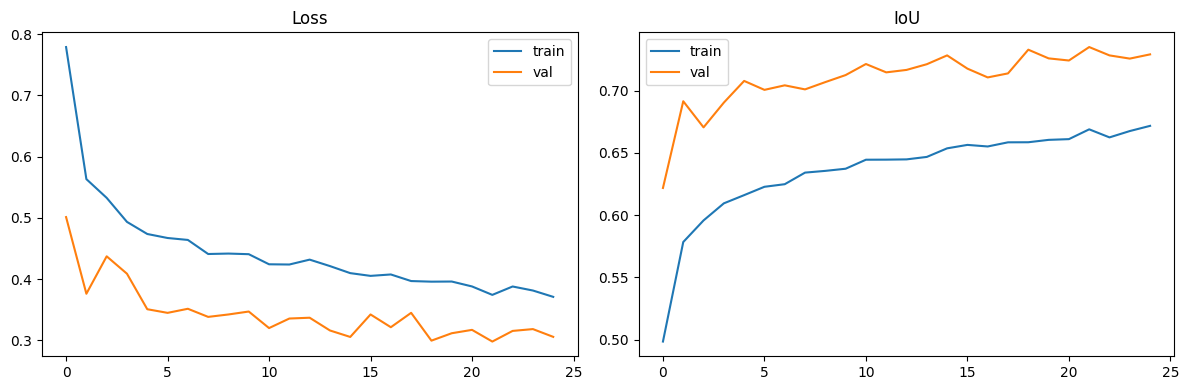

In [12]:
# Plot curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history["train_iou"], label="train")
ax[1].plot(history["val_iou"], label="val")
ax[1].set_title("IoU"); ax[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", dpi=120)
plt.show()


## 5. Inference → Binary Mask → Contours → Centroid (FR-1.x)

Matches functional requirements:
- FR-1.1 Accept grayscale SAR
- FR-1.2 Binary mask (1 = oil)
- FR-1.3 Contours, area (km²), geometric centroid


In [13]:
# Load best weights
ckpt = MODEL_DIR / "unet_resnet34_best.pt"
if ckpt.exists():
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    print("Loaded best checkpoint")
model.eval()

@torch.no_grad()
def predict_mask(model, img_gray, size=256, thr=0.5):
    h, w = img_gray.shape
    img_r = cv2.resize(img_gray, (size, size))
    x = (img_r.astype(np.float32) / 255.0 - 0.5) / 0.5
    x = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).to(DEVICE)
    logits = model(x)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    prob = cv2.resize(prob, (w, h))
    mask = (prob > thr).astype(np.uint8)
    return mask, prob

def extract_slick_geometry(mask, pixel_size_m=10.0):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    results = []
    for cnt in contours:
        area_px = cv2.contourArea(cnt)
        if area_px < 20:
            continue
        peri_px = cv2.arcLength(cnt, True)
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
        area_km2 = area_px * (pixel_size_m ** 2) / 1e6
        peri_m   = peri_px * pixel_size_m
        results.append({
            "area_km2": area_km2,
            "perimeter_m": peri_m,
            "centroid_px": (cx, cy),
            "contour": cnt,
            "area_px": area_px,
        })
    results.sort(key=lambda r: r["area_km2"], reverse=True)
    return results


Loaded best checkpoint


Detected 6 slick(s)
  Main slick area : 0.9859 km²
  Perimeter      : 12394.7 m
  Centroid (px)  : (65.8, 86.3)


FileNotFoundError: [Errno 2] No such file or directory: 'raw_data/outputs/segmentation_demo.png'

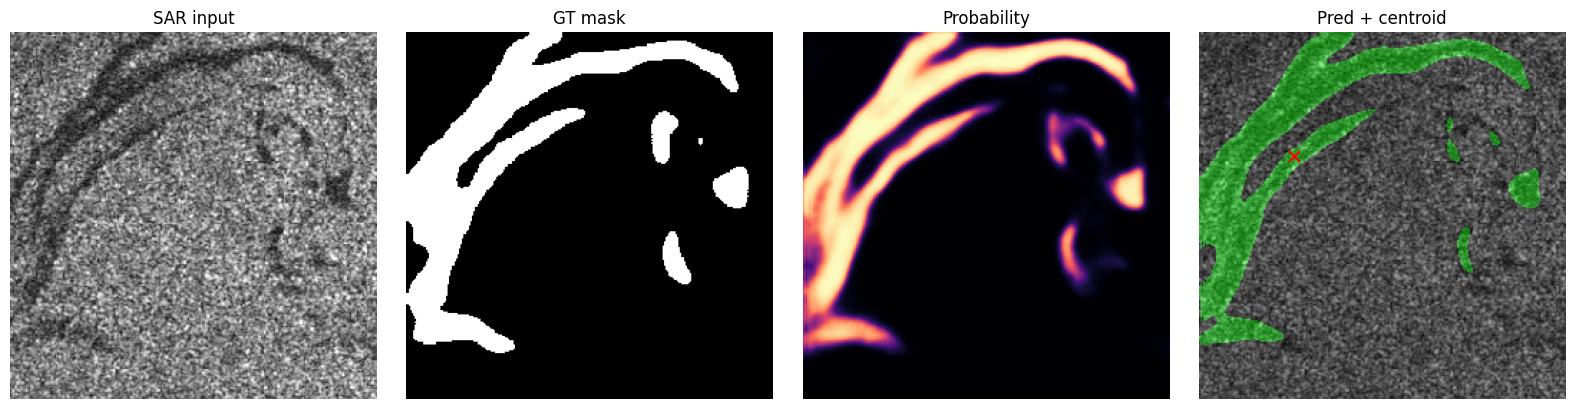

In [16]:
# Demo on first validation image (or synthetic)
demo_img_path, demo_msk_path = val_pairs[0] if val_pairs else train_pairs[0]
demo_img = cv2.imread(demo_img_path, cv2.IMREAD_GRAYSCALE)
demo_gt  = cv2.imread(demo_msk_path, cv2.IMREAD_GRAYSCALE)
demo_gt  = (demo_gt > 127).astype(np.uint8)

pred_mask, pred_prob = predict_mask(model, demo_img)
slicks = extract_slick_geometry(pred_mask, pixel_size_m=10.0)

print(f"Detected {len(slicks)} slick(s)")
if slicks:
    main = slicks[0]
    print(f"  Main slick area : {main['area_km2']:.4f} km²")
    print(f"  Perimeter      : {main['perimeter_m']:.1f} m")
    print(f"  Centroid (px)  : ({main['centroid_px'][0]:.1f}, {main['centroid_px'][1]:.1f})")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(demo_img, cmap="gray"); axes[0].set_title("SAR input")
axes[1].imshow(demo_gt, cmap="gray");  axes[1].set_title("GT mask")
axes[2].imshow(pred_prob, cmap="magma"); axes[2].set_title("Probability")
axes[3].imshow(demo_img, cmap="gray")
overlay = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
overlay[pred_mask == 1] = (0, 255, 0)
axes[3].imshow(overlay, alpha=0.4)
if slicks:
    cx, cy = slicks[0]["centroid_px"]
    axes[3].scatter([cx], [cy], c="red", s=60, marker="x")
axes[3].set_title("Pred + centroid")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "segmentation_demo.png", dpi=130)
plt.show()


## 6. Geo-referencing the Centroid (demo)

In production use the real georeferencing of the Sentinel-1 product (geotransform / GCPs).


In [15]:
def pixel_to_latlon(cx, cy, img_shape, bounds):
    h, w = img_shape
    lon = bounds[0] + (cx / w) * (bounds[2] - bounds[0])
    lat = bounds[3] - (cy / h) * (bounds[3] - bounds[1])
    return lat, lon

DEMO_BOUNDS = (-89.5, 28.0, -88.5, 29.0)   # lon_min, lat_min, lon_max, lat_max
T0 = datetime(2010, 5, 15, 12, 0, 0)

if slicks:
    cx, cy = slicks[0]["centroid_px"]
    lat0, lon0 = pixel_to_latlon(cx, cy, demo_img.shape, DEMO_BOUNDS)
    print(f"Detection time T0     : {T0.isoformat()}")
    print(f"Centroid (Lat0, Lon0): {lat0:.5f}, {lon0:.5f}")
else:
    lat0, lon0 = 28.5, -89.0
    print("No slick detected – using fallback centroid")


Detection time T0     : 2010-05-15T12:00:00
Centroid (Lat0, Lon0): 28.66299, -89.24307


## 7. Phase 2 – Hindcasting (FR-2.x)

Full production uses **OpenDrift + OpenOil** forced by NetCDF currents & wind.  
Here we provide a simplified 2-D Lagrangian advection that runs without external NetCDF.


In [17]:
def simple_hindcast(lat0, lon0, t0,
                    hours_back=18,
                    dt_minutes=30,
                    current_u=0.15,
                    current_v=-0.05,
                    wind_u=3.0,
                    wind_v=1.0,
                    wind_factor=0.03):
    u = current_u + wind_factor * wind_u
    v = current_v + wind_factor * wind_v
    u, v = -u, -v   # reverse

    n_steps = int(hours_back * 60 / dt_minutes)
    traj = [(lat0, lon0, t0)]
    lat, lon = lat0, lon0
    t = t0
    R = 6371000.0
    for _ in range(n_steps):
        dlat = (v * dt_minutes * 60) / R * (180 / np.pi)
        dlon = (u * dt_minutes * 60) / (R * np.cos(np.deg2rad(lat))) * (180 / np.pi)
        lat += dlat
        lon += dlon
        t  -= timedelta(minutes=dt_minutes)
        traj.append((lat, lon, t))
    origin_lat, origin_lon, t_origin = traj[-1]
    return origin_lat, origin_lon, t_origin, traj

origin_lat, origin_lon, t_origin, traj = simple_hindcast(lat0, lon0, T0, hours_back=18)
print(f"Origin time   : {t_origin.isoformat()}")
print(f"Origin (lat, lon): {origin_lat:.5f}, {origin_lon:.5f}")
print(f"Trajectory points: {len(traj)}")


Origin time   : 2010-05-14T18:00:00
Origin (lat, lon): 28.67465, -89.40247
Trajectory points: 37


In [18]:
# Optional real OpenDrift snippet (uncomment when opendrift + NetCDF available)
OPEN_DRIFT_SNIPPET = '''
from opendrift.models.openoil import OpenOil
from opendrift.readers import reader_netCDF_CF_generic

o = OpenOil(loglevel=20)
reader_current = reader_netCDF_CF_generic.Reader("path/to/currents.nc")
reader_wind    = reader_netCDF_CF_generic.Reader("path/to/wind.nc")
o.add_reader([reader_current, reader_wind])
o.seed_elements(lon=lon0, lat=lat0, number=500, time=T0, oil_type="GENERIC LIGHT CRUDE")
o.run(duration=timedelta(hours=-18), time_step=timedelta(minutes=-30))
'''
print("OpenDrift snippet stored in OPEN_DRIFT_SNIPPET (for production use)")


OpenDrift snippet stored in OPEN_DRIFT_SNIPPET (for production use)


## 8. Phase 3 – AIS Correlation & Suspect Ranking (FR-3.x)

- Ingest Marine Cadastre-style CSV  
- Spatio-temporal filter: ±60 min around T_origin, ≤ 3 km  
- Suspicion Index (0–100):
  - Proximity 40 pts
  - Speed anomaly (SOG < 5 kn) 40 pts
  - Vessel profile (tanker / cargo) 20 pts


In [20]:
def make_demo_ais(origin_lat, origin_lon, t_origin, n_vessels=12):
    rows = []
    rng = np.random.RandomState(7)
    rows.append({
        "MMSI": 367123456,
        "BaseDateTime": t_origin.strftime("%Y-%m-%dT%H:%M:%S"),
        "LAT": origin_lat + 0.005,
        "LON": origin_lon - 0.004,
        "SOG": 2.3,
        "COG": 145.0,
        "VesselType": 80,
        "VesselName": "MT DEMO-TANKER"
    })
    for i in range(n_vessels - 1):
        dt = rng.randint(-90, 90)
        t = t_origin + timedelta(minutes=int(dt))
        rows.append({
            "MMSI": 360000000 + i,
            "BaseDateTime": t.strftime("%Y-%m-%dT%H:%M:%S"),
            "LAT": origin_lat + rng.uniform(-0.08, 0.08),
            "LON": origin_lon + rng.uniform(-0.08, 0.08),
            "SOG": rng.uniform(6, 14),
            "COG": rng.uniform(0, 360),
            "VesselType": rng.choice([30, 70, 52, 60]),
            "VesselName": f"VESSEL_{i:02d}"
        })
    return pd.DataFrame(rows)

ais_df = make_demo_ais(origin_lat, origin_lon, t_origin)
ais_path = OUT_DIR / "demo_ais.csv"
ais_df.to_csv(ais_path, index=False)
print("Demo AIS written to", ais_path)
ais_df.head()


OSError: Cannot save file into a non-existent directory: 'raw_data/outputs'

In [21]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.deg2rad, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def suspicion_index(row, origin_lat, origin_lon, t_origin):
    d = haversine_km(row["LAT"], row["LON"], origin_lat, origin_lon)
    prox = max(0.0, 40.0 * (1.0 - d / 3.0))
    sog = row["SOG"]
    speed = 40.0 if sog < 5.0 else max(0.0, 40.0 * (1.0 - (sog - 5.0) / 10.0))
    vt = int(row["VesselType"])
    if vt in (80, 89):
        profile = 20.0
    elif vt in (70, 79):
        profile = 15.0
    elif vt in (30, 31, 32):
        profile = 5.0
    else:
        profile = 8.0
    return prox + speed + profile, d

def rank_suspects(ais_df, origin_lat, origin_lon, t_origin,
                  time_tol_min=60, dist_km=3.0):
    df = ais_df.copy()
    df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])
    t0 = pd.Timestamp(t_origin)
    mask_time = (df["BaseDateTime"] - t0).abs() <= pd.Timedelta(minutes=time_tol_min)
    candidates = df[mask_time].copy()
    if candidates.empty:
        return candidates
    scores, dists = [], []
    for _, r in candidates.iterrows():
        s, d = suspicion_index(r, origin_lat, origin_lon, t_origin)
        scores.append(s)
        dists.append(d)
    candidates["distance_km"] = dists
    candidates["suspicion"] = scores
    candidates = candidates[candidates["distance_km"] <= dist_km]
    candidates = candidates.sort_values("suspicion", ascending=False)
    return candidates

suspects = rank_suspects(ais_df, origin_lat, origin_lon, t_origin)
print("Top suspects:")
print(suspects[["MMSI", "VesselName", "VesselType", "SOG", "distance_km", "suspicion"]].head(5).to_string(index=False))

if len(suspects):
    top = suspects.iloc[0]
    print(f"\n★ Primary suspect MMSI {int(top.MMSI)} | score {top.suspicion:.1f}/100")
else:
    print("No vessel inside the spatio-temporal window")


Top suspects:
     MMSI     VesselName  VesselType  SOG  distance_km  suspicion
367123456 MT DEMO-TANKER          80  2.3      0.67925  90.943329

★ Primary suspect MMSI 367123456 | score 90.9/100


## 9. Operator View – Map & Summary (FR-4.x)


In [22]:
import folium
from folium.plugins import MeasureControl

m = folium.Map(location=[lat0, lon0], zoom_start=9, tiles="CartoDB positron")

folium.CircleMarker(
    location=[lat0, lon0], radius=8, color="red", fill=True,
    popup=f"Detection T0<br>{T0.isoformat()}<br>{lat0:.4f}, {lon0:.4f}"
).add_to(m)

traj_coords = [[p[0], p[1]] for p in traj]
folium.PolyLine(traj_coords, color="orange", weight=3, dash_array="8,6",
                popup="Reverse drift path").add_to(m)

folium.Marker(
    location=[origin_lat, origin_lon],
    icon=folium.Icon(color="orange", icon="info-sign"),
    popup=f"Estimated origin<br>{t_origin.isoformat()}"
).add_to(m)

for _, r in ais_df.iterrows():
    color = "red" if (len(suspects) and r.MMSI == suspects.iloc[0].MMSI) else "blue"
    folium.CircleMarker(
        location=[r.LAT, r.LON], radius=5, color=color, fill=True,
        popup=f"{r.VesselName}<br>MMSI {r.MMSI}<br>SOG {r.SOG} kn"
    ).add_to(m)

m.add_child(MeasureControl())
map_path = OUT_DIR / "operator_map.html"
m.save(str(map_path))
print("Interactive map saved →", map_path)
m


FileNotFoundError: [Errno 2] No such file or directory: 'raw_data/outputs/operator_map.html'

In [23]:
print("=" * 60)
print("INCIDENT SUMMARY")
print("=" * 60)
print(f"Detection time (T0)     : {T0.isoformat()}")
print(f"Slick centroid          : {lat0:.5f}, {lon0:.5f}")
if slicks:
    print(f"Estimated area          : {slicks[0]['area_km2']:.3f} km²")
print(f"Hindcast origin time    : {t_origin.isoformat()}")
print(f"Hindcast origin coords  : {origin_lat:.5f}, {origin_lon:.5f}")
print("-" * 60)
if len(suspects):
    top = suspects.iloc[0]
    print(f"PRIMARY SUSPECT")
    print(f"  MMSI                  : {int(top.MMSI)}")
    print(f"  Name                  : {top.VesselName}")
    print(f"  Type code             : {int(top.VesselType)}")
    print(f"  SOG at origin window  : {top.SOG:.1f} kn")
    print(f"  Distance to origin    : {top.distance_km:.2f} km")
    print(f"  Suspicion Index       : {top.suspicion:.1f} / 100")
else:
    print("No vessel met the spatio-temporal criteria.")
print("=" * 60)


INCIDENT SUMMARY
Detection time (T0)     : 2010-05-15T12:00:00
Slick centroid          : 28.66299, -89.24307
Estimated area          : 0.986 km²
Hindcast origin time    : 2010-05-14T18:00:00
Hindcast origin coords  : 28.67465, -89.40247
------------------------------------------------------------
PRIMARY SUSPECT
  MMSI                  : 367123456
  Name                  : MT DEMO-TANKER
  Type code             : 80
  SOG at origin window  : 2.3 kn
  Distance to origin    : 0.68 km
  Suspicion Index       : 90.9 / 100


## 10. Optional – YOLOv8-seg Training

Uncomment and run if you prefer instance segmentation over U-Net.


In [ ]:
def mask_to_yolo_seg(mask, class_id=0):
    h, w = mask.shape
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    lines = []
    for cnt in contours:
        if cv2.contourArea(cnt) < 10:
            continue
        pts = cnt.reshape(-1, 2).astype(float)
        pts[:, 0] /= w
        pts[:, 1] /= h
        flat = " ".join([f"{x:.6f} {y:.6f}" for x, y in pts])
        lines.append(f"{class_id} {flat}")
    return lines

print("YOLOv8-seg conversion helpers ready.")
print("Typical train command:")
print('''
from ultralytics import YOLO
model = YOLO("yolov8n-seg.pt")
model.train(data="data.yaml", epochs=100, imgsz=640, batch=8,
            hsv_h=0, hsv_s=0, copy_paste=0.3, close_mosaic=10)
''')


## 11. Single-call End-to-End Function

In [ ]:
def run_pipeline(sar_path,
                 ais_csv=None,
                 t0=None,
                 bounds=None,
                 pixel_size_m=10.0,
                 hours_back=18):
    t0 = t0 or datetime.utcnow()
    bounds = bounds or (-89.5, 28.0, -88.5, 29.0)

    img = cv2.imread(str(sar_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(sar_path)

    mask, prob = predict_mask(model, img)
    slicks = extract_slick_geometry(mask, pixel_size_m=pixel_size_m)
    if not slicks:
        return {"status": "no_slick_detected", "mask": mask}

    main = slicks[0]
    lat0, lon0 = pixel_to_latlon(*main["centroid_px"], img.shape, bounds)
    origin_lat, origin_lon, t_origin, traj = simple_hindcast(lat0, lon0, t0, hours_back=hours_back)

    if ais_csv is None:
        ais_df = make_demo_ais(origin_lat, origin_lon, t_origin)
    else:
        ais_df = pd.read_csv(ais_csv)

    suspects = rank_suspects(ais_df, origin_lat, origin_lon, t_origin)
    top = suspects.iloc[0].to_dict() if len(suspects) else None

    return {
        "status": "ok",
        "T0": t0.isoformat(),
        "centroid_latlon": (lat0, lon0),
        "area_km2": main["area_km2"],
        "origin_latlon": (origin_lat, origin_lon),
        "T_origin": t_origin.isoformat(),
        "trajectory": traj,
        "top_suspect": top,
        "all_suspects": suspects,
        "mask": mask,
        "prob": prob,
    }

result = run_pipeline(demo_img_path, t0=T0)
print(json.dumps({k: v for k, v in result.items()
                  if k not in ("mask", "prob", "trajectory", "all_suspects")},
                 indent=2, default=str))


## 12. Production Notes & Next Steps

| Component | Demo status | Production upgrade |
|-----------|-------------|--------------------|
| Segmentation | U-Net ResNet34 on refined SOS | Increase epochs, add more Sentinel-1 scenes, TTA |
| Geo-ref | Simulated bounds | Real Sentinel-1 geotransform / SNAP / GDAL |
| Hindcast | Simple advection | OpenDrift + OpenOil + Copernicus / ECMWF NetCDF |
| AIS | Synthetic CSV | Marine Cadastre historical or live Satellite-AIS |
| Dashboard | Folium HTML | Full Streamlit app (file uploader + scenario dropdown) |

### Streamlit skeleton (save as `app.py`)
```python
import streamlit as st
from pipeline import run_pipeline
st.title("SAR Oil Spill Operator Dashboard")
uploaded = st.file_uploader("SAR chip", type=["png","tif","jpg"])
if uploaded:
    result = run_pipeline(...)
    st.metric("Suspicion", result["top_suspect"]["suspicion"])
```

### File layout produced by this notebook
```
oil_spill_pipeline/
  data/sos/...
  models/unet_resnet34_best.pt
  outputs/
    training_curves.png
    segmentation_demo.png
    operator_map.html
    demo_ais.csv
```
